In [24]:
from utils import DQN, ReplayBuffer, greedy_action, epsilon_greedy, update_target, loss

import torch # ML library 
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import math
import numpy as np

import gym # provides various RL environments
import matplotlib.pyplot as plt

import os
import fnmatch
import logging 

In [2]:
# Logging configuration (put this right after imports)

# experiment_directory = "experiments" # CREATE THIS DIRECTORY BEFORE RUNNING THE CODE

# # Find existing log files and get the highest number
# existing_plots = fnmatch.filter(os.listdir(experiment_directory), 'plot_*.png')
# if existing_plots:
#     existing_numbers = [int(plot.split('_')[1].split('.')[0]) for plot in existing_plots]
#     plot_number = max(existing_numbers) + 1
# else:
#     plot_number = 1
    
# logging.basicConfig(filename=f"experiments/training_log.log",
#                     level=logging.INFO,
#                     format='%(asctime)s - %(levelname)s - %(message)s'
#                     )



In [20]:
# Parameters 
NUM_RUNS = 3
# EPSILON = 0.1     # placeholder value - you should implement your own exploration schedule
# lr = 0.01 # original 
initial_lr = 1
num_episodes = 300
# batch_size = 36 # original 
batch_size = 128
buffer_size = 100000
update_period = 15
decay_rate = 0.98 # for epsilon
initial_epsilon = 1
min_epsilon = 0.1
min_alpha = 0.001

In [27]:
activations = ['relu', 'sigmoid', 'tanh']  # Example activations to compare
results = {}  # Store results for different activations
env = gym.make('CartPole-v1')

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]/n
plt.figure(figsize=(8, 4)) # width:height

for activation in activations:
    all_runs = []
    for run in range(NUM_RUNS):
        print(f"Starting run {run+1} of {NUM_RUNS}")

        # architecture = [4, 50, 50, 2] # original 
        architecture = [4, 32, 32, 2] # increasing size better than increasing number 
        policy_net = DQN(architecture, activation = activation) # input = 4 and output = 2 (0 or 1) 
        target_net = DQN(architecture, activation = activation)
        update_target(target_net, policy_net)
        target_net.eval()
        
        # Layer size
        layer_size = architecture[1]

        # Learning rate
        lr = initial_lr

        # optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
        # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
        memory = ReplayBuffer(buffer_size) # 1 originally 
        steps_done = 0
        episode_durations = []

        EPSILON = initial_epsilon

        for i_episode in range(num_episodes): # can adjust num_episodes 
            lr = max(min_alpha, lr*0.955) #lr *= 0.955
            optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
            if (i_episode+1) % 50 == 0:
                print("episode ", i_episode+1, "/", 300)

            observation, info = env.reset()
            state = torch.tensor(observation).float()

            done = False
            terminated = False
            t = 0
            # EPSILON = max(1/(i_episode+1), min_epsilon) # original 
            EPSILON = max(EPSILON*decay_rate, min_epsilon)
            while not (done or terminated):

                # Select and perform an action
                action = epsilon_greedy(EPSILON, policy_net, state)
                # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                observation, reward, done, terminated, info = env.step(action)
                reward = torch.tensor([reward])
                action = torch.tensor([action])
                next_state = torch.tensor(observation).reshape(-1).float()

                # store in replay buffer
                memory.push([state, action, next_state, reward, torch.tensor([done])])

                # Move to the next state
                state = next_state

                # Perform one step of the optimization (on the policy network)
                if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                    transitions = memory.sample(batch_size) # sample one transition from buffer
                    state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                    # Compute loss
                    mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                    # Optimize the model
                    optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                    mse_loss.backward() # store gradient of the loss wrt each para 
                    optimizer.step() # carry out gradient dedscent step & update of para 
                
                if done or terminated:
                    episode_durations.append(t + 1)
                t += 1
            # Update the target network, copying all weights and biases in DQN
            if i_episode % update_period == 0: 
                update_target(target_net, policy_net)
        # results[activation] = episode_durations
        all_runs.append(episode_durations)

        # Compute the average of results for each run using moving average
    averaged_results = np.mean([moving_average(run_result) for run_result in all_runs], axis=0)
    results[activation] = averaged_results

    # Plot the averaged results
    plt.plot(averaged_results, label=f"α = {activation}", linewidth = 0.8, alpha = 0.8)
    print('Complete')

plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc='upper left') 
plt.xlabel('episode')
plt.ylabel('return')
plt.title("Learning curve: return vs episode number during training for different activation functions (5 runs)")
plt.show()

Starting run 1 of 3


TypeError: DQN.__init__() got an unexpected keyword argument 'activation'

<Figure size 800x400 with 0 Axes>

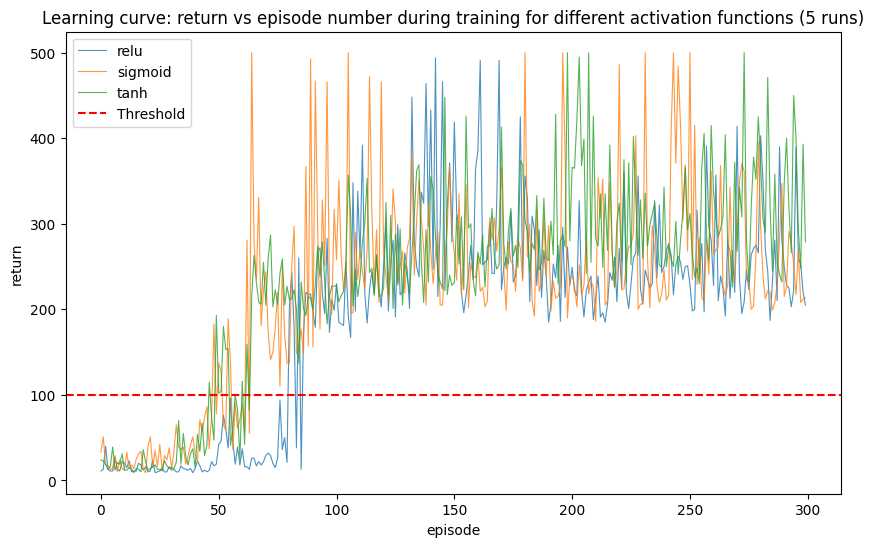

In [8]:
# Plotting the learning curves
plt.figure(figsize=(10, 6))
for activation, durations in results.items():
    plt.plot(durations, label=activation, linewidth = 0.8, alpha = 0.8)

plt.xlabel('episode')
plt.ylabel('return')
plt.legend()
plt.title("Learning curve: return vs episode number during training for different activation functions (5 runs)")
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc = 'upper left')  # Add a legend to label the threshold line
# plt.savefig(f'experiments/plot_{plot_number}.png') # ADD THIS LINE TO SAVE THE PLOT IN THE EXPERIMENTS DIRECTORY

plt.show()


In [ ]:
# plt.savefig("C:/Users/yhara/OneDrive - Imperial College London/YEAR 4/RL/Figure2.svg")

In [ ]:
logging.info(f"Hyperparameters: plot_number={plot_number}, NUM_RUNS={NUM_RUNS}, NUM_EP={num_episodes}, INITIAL_EPSILON={initial_epsilon}, BUFFER_SIZE={buffer_size} EPSILON_DECAY_RATE={decay_rate}, UPDATE_PERIOD={update_period}, BATCH_SIZE={batch_size}, ALPHA={lr}, LAYER_SIZES={layer_size}, QUANTIFY_MEAN={quantify_results}, QUANTIFY_STD={quantify_std}")

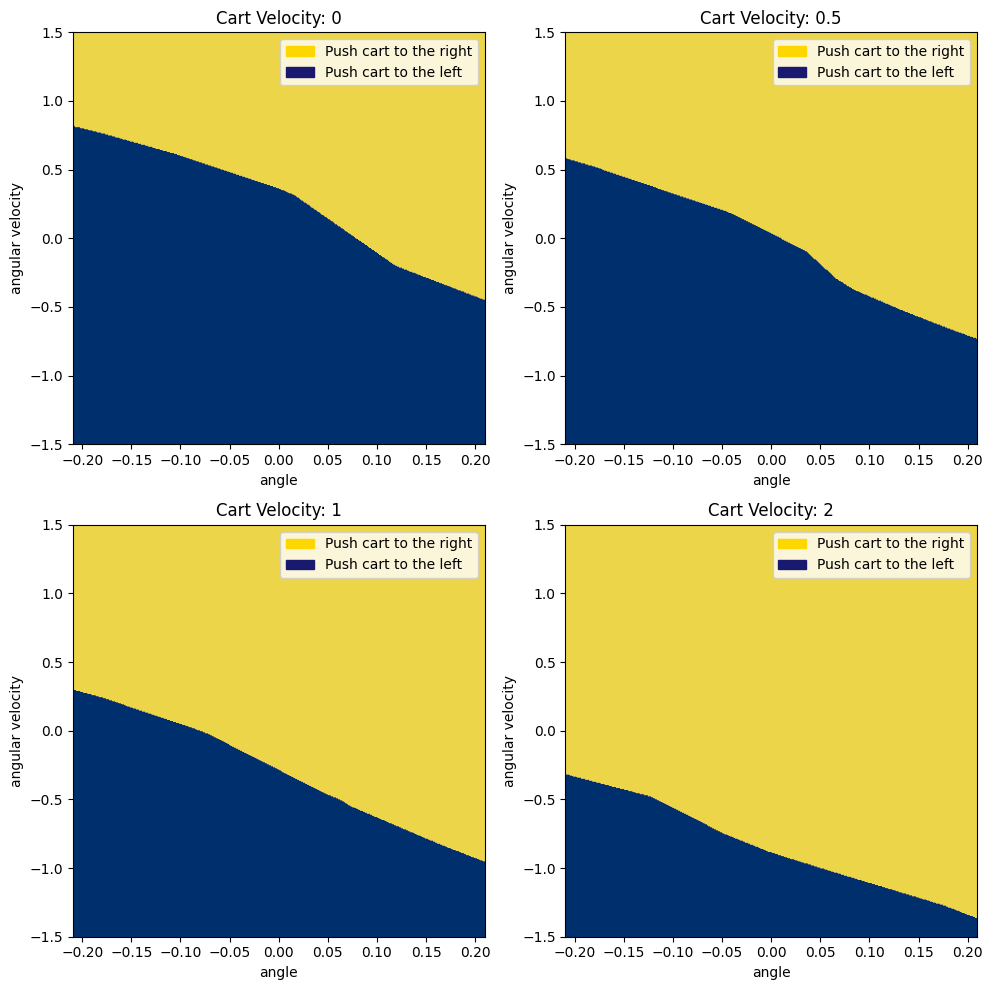

Text(0.5, 1.0, 'Greedy action policy')

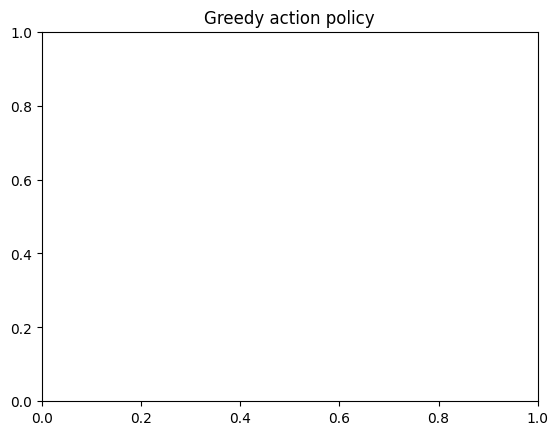

In [ ]:
# Visualising the greedy Q-values for a stationary cart in the middle of the track
# 2D plot showing policy as a function of pole angle and angular velocity (omega)

# This plots the policy and Q values according to the network currently
# stored in the variable "policy_net"

# All visualisations provided here are placeholders and you can modify these plots

# Make sure to include appropriate labels and/or legends when presenting your plot

# policy_net = DQN([4,2])   # randomly initialised, replace with your trained DQN

import matplotlib.patches as mpatches

q = False    # whether q values or greedy policy is visualised

angle_range = .2095 # you may modify this range
# angle_range = .4018
omega_range = 1.5     # you may modify this range
# omega_range = 1.0

angle_samples = 400 # was originially 100 
omega_samples = 400
angles = torch.linspace(angle_range, -angle_range, angle_samples) # 100 samples between -0.2095 and +0.2095 
omegas = torch.linspace(-omega_range, omega_range, omega_samples)

velocities = [0, 0.5, 1, 2]

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for idx, velocity in enumerate(velocities):
    greedy_q_array = torch.zeros((angle_samples, omega_samples))
    policy_array = torch.zeros((angle_samples, omega_samples))

    for i, angle in enumerate(angles):
        for j, omega in enumerate(omegas):
            state = torch.tensor([0, velocity, angle, omega])
            with torch.no_grad():
                q_vals = policy_net(state)
                greedy_action = q_vals.argmax()
                greedy_q_array[i, j] = q_vals[greedy_action]
                policy_array[i, j] = greedy_action
    if q:
        im = axs[idx // 2, idx % 2].contourf(angles, omegas, greedy_q_array.T, cmap='cividis', levels=100)
    
    else:
        im = axs[idx // 2, idx % 2].contourf(angles, omegas, policy_array.T, cmap='cividis')
        
    legend_patches = [mpatches.Patch(color = 'gold', label = 'Push cart to the right'), mpatches.Patch(color='midnightblue', label = 'Push cart to the left')]
    # plt.legend(handles = legend_patches)
    axs[idx // 2, idx % 2].legend(handles=legend_patches, loc='upper right')

    axs[idx // 2, idx % 2].set_xlabel("angle")
    axs[idx // 2, idx % 2].set_ylabel("angular velocity")
    axs[idx // 2, idx % 2].set_title(f"Cart Velocity: {velocity}")
    
    
    
    # Create a colorbar as a legend
    # cbar = fig.colorbar(im, ax=axs[idx // 2, idx % 2])
    # cbar.set_ticks([0.25, 0.75])  # Set ticks at positions corresponding to the middle of each class
    # cbar.set_ticklabels(['left', 'right'])  # Set tick labels as 'left' and 'right'

plt.tight_layout()
plt.show()
plt.title('Greedy action policy')